# WaveSplit

### Učitavanje biblioteka

In [27]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import torch
from demucs.pretrained import get_model
from demucs.apply import apply_model

### Putanja do audio fajla

In [55]:
audio_path = './songs/bob_marley_three_little_birds.wav'

### Učitavanje Demucs modela

In [56]:
model = get_model(name='htdemucs')
model.eval()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

print(f'Demucs model je učitan: {device}')

Demucs model je učitan: cpu


### Učitavanje audio fajla

In [57]:
wav, sr = librosa.load(path=audio_path, sr=44100, mono=False)

if wav.ndim == 1:
    wav = np.stack([wav, wav])

wav = torch.tensor(wav, dtype=torch.float32)
wav = wav.to(device)

wav = wav.unsqueeze(0)

### Podela instrumenata

In [58]:
output_root = './separated'
os.makedirs(output_root, exist_ok=True)

file_name = os.path.splitext(os.path.basename(audio_path))[0]

song_folder = os.path.join(output_root, file_name)
os.makedirs(song_folder, exist_ok=True)

print(f'{song_folder} folder je kreiran.')

with torch.no_grad():
    sources = apply_model(model, wav)

sources = sources[0]

source_names = ['drums', 'bass', 'other', 'vocals']

separated = {}

for i, name in enumerate(source_names):
    audio = sources[i].cpu().numpy()

    audio = np.transpose(audio)

    path = os.path.join(song_folder, f'{file_name}_{name}.wav')
    sf.write(path, audio, sr)

    separated[name] = audio

    print(f'Sačuvano: {path}')

./separated\bob_marley_three_little_birds folder je kreiran.
Sačuvano: ./separated\bob_marley_three_little_birds\bob_marley_three_little_birds_drums.wav
Sačuvano: ./separated\bob_marley_three_little_birds\bob_marley_three_little_birds_bass.wav
Sačuvano: ./separated\bob_marley_three_little_birds\bob_marley_three_little_birds_other.wav
Sačuvano: ./separated\bob_marley_three_little_birds\bob_marley_three_little_birds_vocals.wav


### Učitavanje audio fajla - pesme

In [35]:
signal, sr = librosa.load(
    path=audio_path,
    sr=44100,
    mono=True
)

*Sample rate* standardizujemo na 44100Hz - to znači da postoji 44100 uzoraka u sekundi.

Takodje stereo signal pretvaramo u *mono* kako bi nam analiza i Short-time Fourier Transormation (STFT) bila lakša.

### Normalizacija signala

Normalizaciju signala radimo sa ciljem kako bismo amplitude signala ograničili intervalom od -1 do 1.

In [36]:
signal = signal / np.max(np.abs(signal))

### Prikaz osnovnih informacija o audio fajlu

In [5]:
print(f'Sample Rate: {sr}[Hz]')
print(f'Broj uzoraka: {len(signal)}')
print(f'Trajanje pesme: {round(len(signal) / sr, 2)} sekundi')

Sample Rate: 44100[Hz]
Broj uzoraka: 11410432
Trajanje pesme: 258.74 sekundi


### Detekcija Onset-a

In [37]:
onset_env = librosa.onset.onset_strength(
    y=signal,
    sr=sr
)

Nakon što librosa interno uradi STFT, meri se koliko se spektar promenio između frame-ova. Iz toga se dobija niz vrednosti, te ukoliko je vrednost velika, to predstavlja veliku promenu energije, dok mala vrednost predstavlja stabilan signal.

*Onset strength envelope* prikazuje gde se dešavaju ritmički udarci.

### Prikaz onset envelop-a

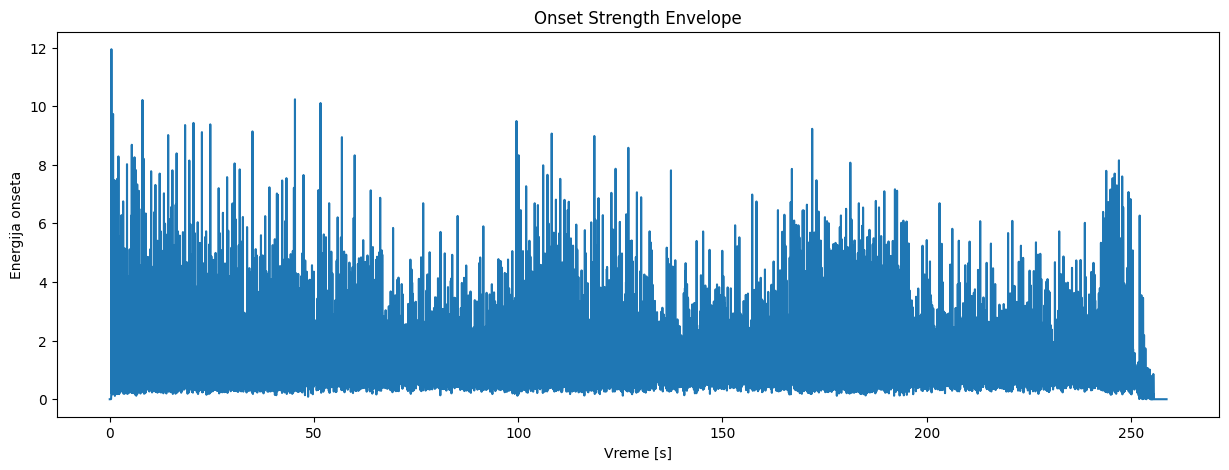

In [38]:
times = librosa.times_like(
    onset_env,
    sr=sr
)
plt.figure(figsize=(15, 5))
plt.plot(times, onset_env)
plt.title('Onset Strength Envelope')
plt.xlabel('Vreme [s]')
plt.ylabel('Energija onseta')
plt.show()

### Detekcija BPM-a

Librosa ovde analizira periodičnost onset-a, pronalazi dominantni tempo i određuje poziciju beat-ova.

**Potencijalni problem:** Half-time ili Double-time

Ovaj problem nastaje jer se periodicnost može detektovati na više nivoa. Na primer, može se desiti da je tempo pesme 70bpm, a da algoritam vrati 140bpm ili obrnuto. Ovaj problem ćemo kasnije rešiti detekcijom tempa iz izolovanih perkusija.

In [39]:
tempo, beat_frames = librosa.beat.beat_track(
    onset_envelope=onset_env,
    sr=sr
)
tempo = tempo[0]
print(f'Detektovani BPM: {round(float(tempo), 1)}bpm')

Detektovani BPM: 114.8bpm


### Konverzija Frame-ova u vreme

In [40]:
beat_times = librosa.frames_to_time(
    beat_frames,
    sr=sr
)

### Prikaz waveform-a sa BPM-om

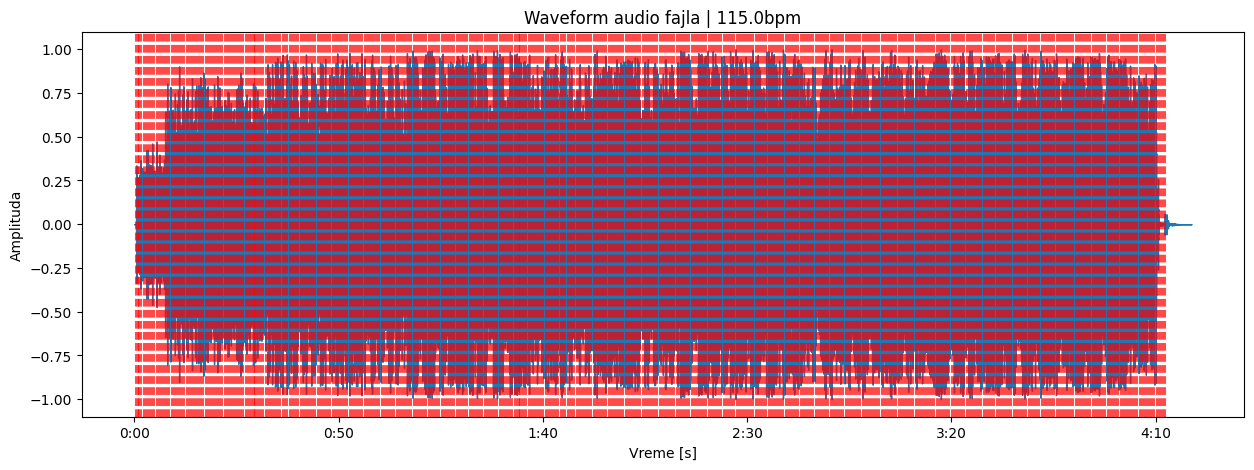

In [41]:
plt.figure(figsize=(15, 5))
librosa.display.waveshow(
    signal,
    sr=sr
)

for beat in beat_times:
    plt.axvline(
        x=beat,
        color='red',
        linestyle='--',
        alpha=0.7
    )

plt.title(f'Waveform audio fajla | {round(float(tempo), 0)}bpm')
plt.xlabel('Vreme [s]')
plt.ylabel('Amplituda')
plt.show()

### Short-Time Fourier Transformation

In [42]:
n_fft = 2048    # velicina FFT prozora
hop_length = 512    # velicina pomeraja izmedju frame-ova

In [43]:
stft = librosa.stft(
    signal,
    n_fft=n_fft,
    hop_length=hop_length
)

### Spektogram

In [44]:
spectogram = np.abs(stft)

In [45]:
# Konverzija u decibele [dB]
spectogram_db = librosa.amplitude_to_db(
    spectogram,
    ref=np.max
)

### Prikaz spektograma

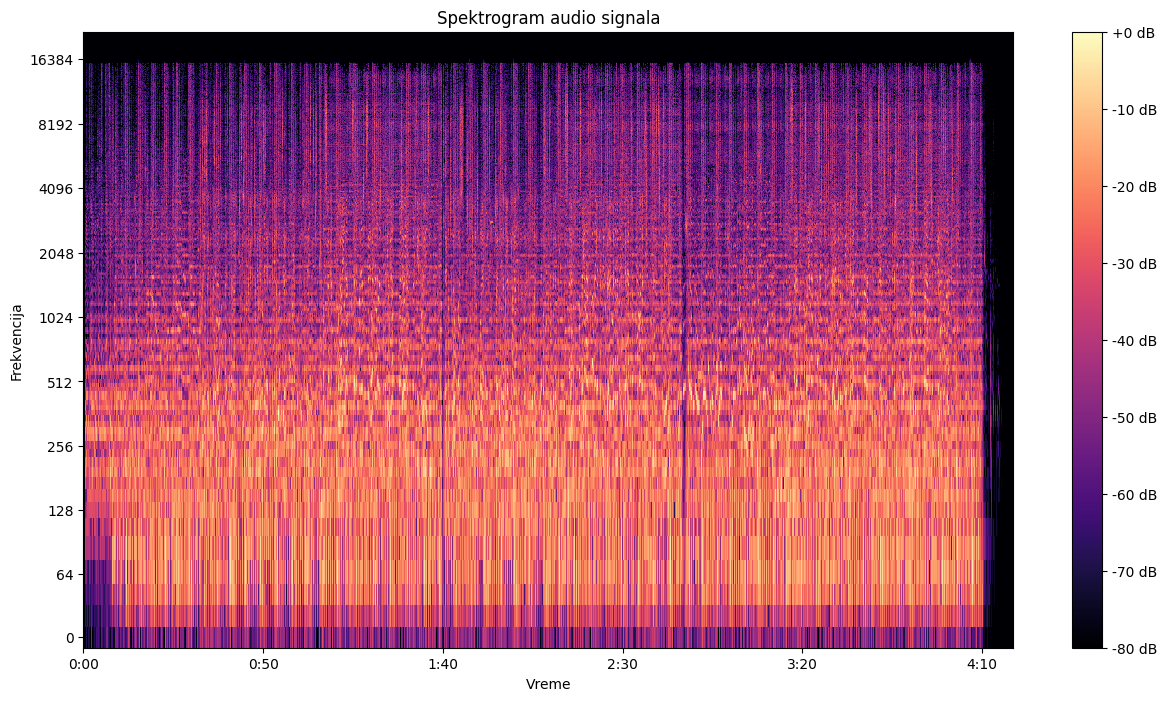

In [46]:
plt.figure(figsize=(15, 8))
librosa.display.specshow(
    spectogram_db,
    sr=sr,
    hop_length=hop_length,
    y_axis='log',
    x_axis='time'
)
plt.colorbar(format='%+2.0f dB')
plt.title("Spektrogram audio signala")
plt.xlabel("Vreme")
plt.ylabel("Frekvencija")
plt.show()

### Chroma feature extraction

**Chroma** predstavlja energiju svih nota nezavisno od oktava.



In [47]:
chroma = librosa.feature.chroma_stft(
    y=signal,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length
)
print(f'Chroma shape: {chroma.shape}')

Chroma shape: (12, 22287)


### Prikaz chroma feature-a

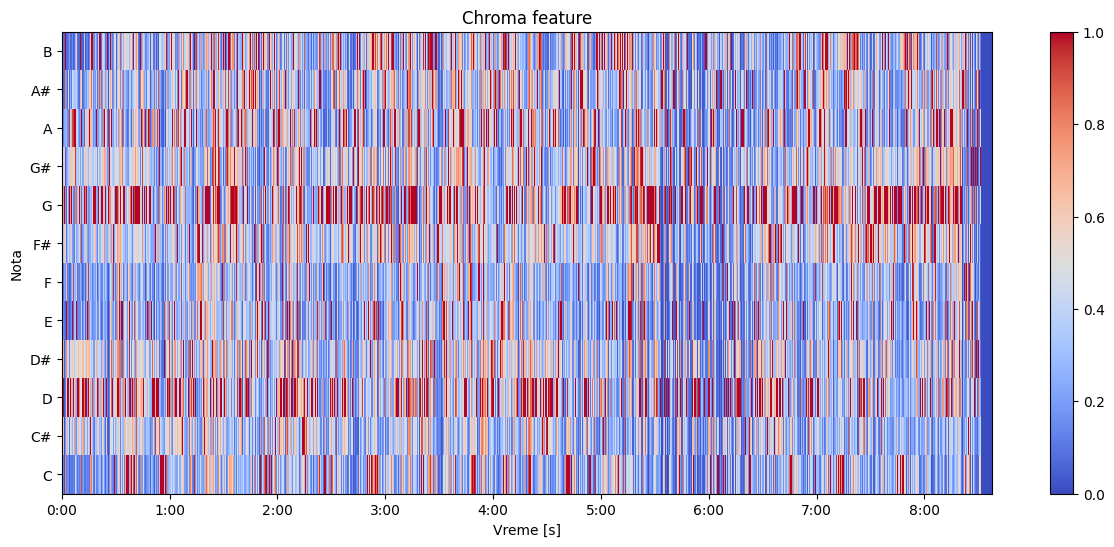

In [48]:
plt.figure(figsize=(15, 6))

librosa.display.specshow(
    chroma,
    x_axis='time',
    y_axis=None,
    hop_length=hop_length,
    cmap='coolwarm'
)

plt.yticks(
    np.arange(12),
    ['C', 'C#', 'D', 'D#', 'E', 'F',
     'F#', 'G', 'G#', 'A', 'A#', 'B']
) # na y-osi smo ovako predstavili note, zato što se bez toga prikazuju samo note u C maj

plt.colorbar()
plt.title('Chroma feature')
plt.xlabel('Vreme [s]')
plt.ylabel('Nota')
plt.show()

### Prikaz prosečne energije svake note

In [49]:
chroma_mean = np.mean(chroma, axis=1)

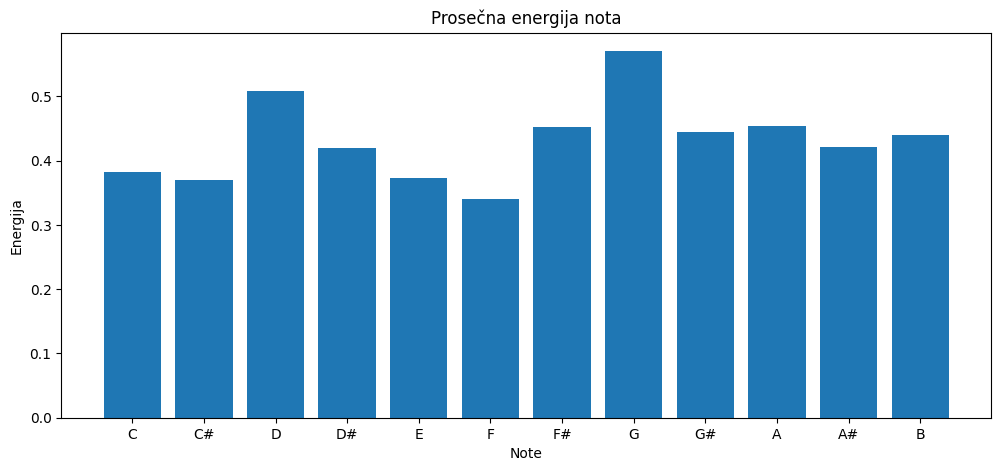

In [50]:
notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

plt.figure(figsize=(12, 5))

plt.bar(notes, chroma_mean)

plt.title('Prosečna energija nota')
plt.xlabel('Note')
plt.ylabel('Energija')

plt.show()

### Krumhansl-Schmuckler (K-S) profili

**K-S algoritam** predstalvja najpoznatiji algoritam za pronalaženje tonaliteta.

**K-S profili** predstavljaju statističke modele, tačnije "tipične važnosti" svake note u major i minor tonalitetu.

In [51]:
major_profile = np.array([
    6.35, 2.23, 3.48, 2.33,
    4.38, 4.09, 2.52, 5.19,
    2.39, 3.66, 2.29, 2.88
])

minor_profile = np.array([
    6.33, 2.68, 3.52, 5.38,
    2.60, 3.53, 2.54, 4.75,
    3.98, 2.69, 3.34, 3.17
])

### Poredjenje sa svim tonalitetima

In [52]:
major_scores = []
minor_scores = []

for i in range(12):

    rotated_major = np.roll(major_profile, i)
    rotated_minor = np.roll(minor_profile, i)

    major_corr = np.corrcoef(
        chroma_mean,
        rotated_major
    )[0, 1]

    minor_corr = np.corrcoef(
        chroma_mean,
        rotated_minor
    )[0, 1]

    major_scores.append(major_corr)
    minor_scores.append(minor_corr)

### Vizualizacija korelacija

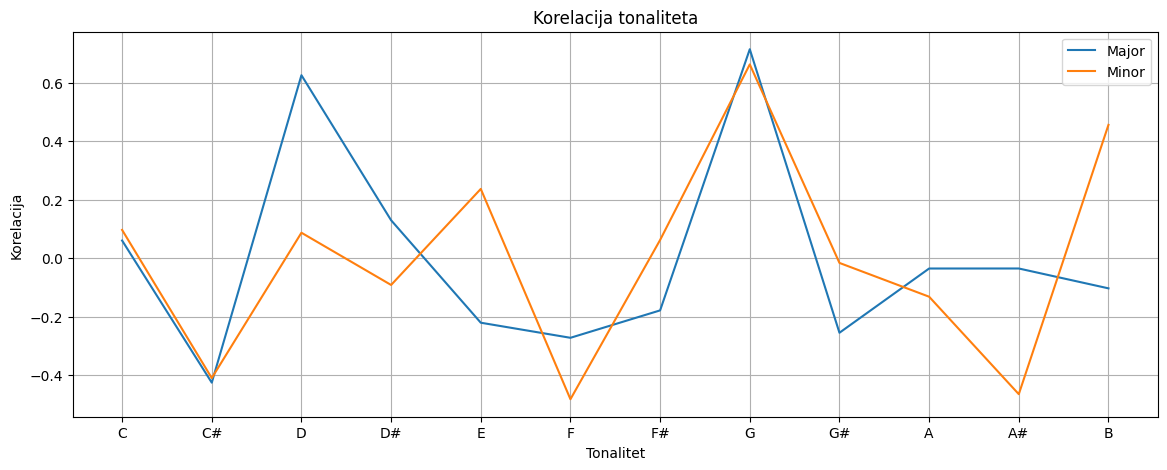

In [53]:
plt.figure(figsize=(14, 5))

plt.plot(notes, major_scores, label='Major')
plt.plot(notes, minor_scores, label='Minor')

plt.title('Korelacija tonaliteta')
plt.xlabel('Tonalitet')
plt.ylabel('Korelacija')

plt.legend()
plt.grid()

plt.show()

### Odabir najboljeg tonaliteta

In [54]:
best_major = np.argmax(major_scores)
best_minor = np.argmax(minor_scores)

major_score = major_scores[best_major]
minor_score = minor_scores[best_minor]

if major_score > minor_score:
    detected_key = f"{notes[best_major]} Major"
    confidence = major_score
else:
    detected_key = f"{notes[best_minor]} Minor"
    confidence = minor_score

print(f'Detektovani tonalitet: {detected_key}')
print(f'Pouzdanost: {confidence:.3f}')

Detektovani tonalitet: G Major
Pouzdanost: 0.715
